# Lab: Principal Component Analysis with scikit-learn

In the [theory notes](./09_dimension_reduction_algorithms_theory.md), we learned that PCA is the most common *linear* dimensionality reduction technique — it finds new axes (principal components) that maximize the variance in the data, and these axes are orthogonal to each other.

In the [implementation file](./10_pca_implementation.py), we built PCA from scratch — centering data, computing the covariance matrix, extracting eigenvalues/eigenvectors, and projecting onto the top components.

**Now it's time to use the real library.** In this lab, we'll learn how to:

1. Load data and apply scikit-learn's `PCA`.
2. **Understand what PCA gives us** — explained variance, components, and the transformed space.
3. **Choose how many components to keep** using the explained variance ratio and the cumulative variance curve.
4. **Visualize what principal components mean** — biplot arrows showing which original features drive each component.
5. **See the effect of scaling** — why `StandardScaler` is critical for PCA.
6. **Use PCA for visualization** — projecting high-dimensional data into 2D and 3D.
7. **Reconstruct data from reduced dimensions** — understanding information loss.

---

## 1. The Dataset

We'll use the **Iris dataset** — 150 samples of iris flowers with 4 numeric features:
- sepal length, sepal width, petal length, petal width (all in cm)
- 3 species: setosa, versicolor, virginica

This is a classic PCA dataset because:
- It's small enough to fully understand what's happening.
- The 4 features are correlated (petal length and petal width are strongly related), so PCA can compress them effectively.
- The 3 species are partially separable in the reduced space, showing PCA's power for visualization.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the Iris dataset
iris = load_iris()
feature_names = iris.feature_names
target_names = iris.target_names

iris_df = pd.DataFrame(data=iris.data, columns=feature_names)
iris_df['target'] = target_names[iris.target]

print(f"Dataset: {iris_df.shape[0]} samples, {len(feature_names)} features")
print(f"Features: {feature_names}")
print(f"Species: {list(target_names)}")
print()
iris_df.sample(5, random_state=42)

Dataset: 150 samples, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica
78,6.0,2.9,4.5,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor


---

## 2. Why PCA Works: Feature Correlations

PCA is most effective when features are **correlated**. If features were completely independent, there would be nothing to compress. Let's check the correlation structure of our data:

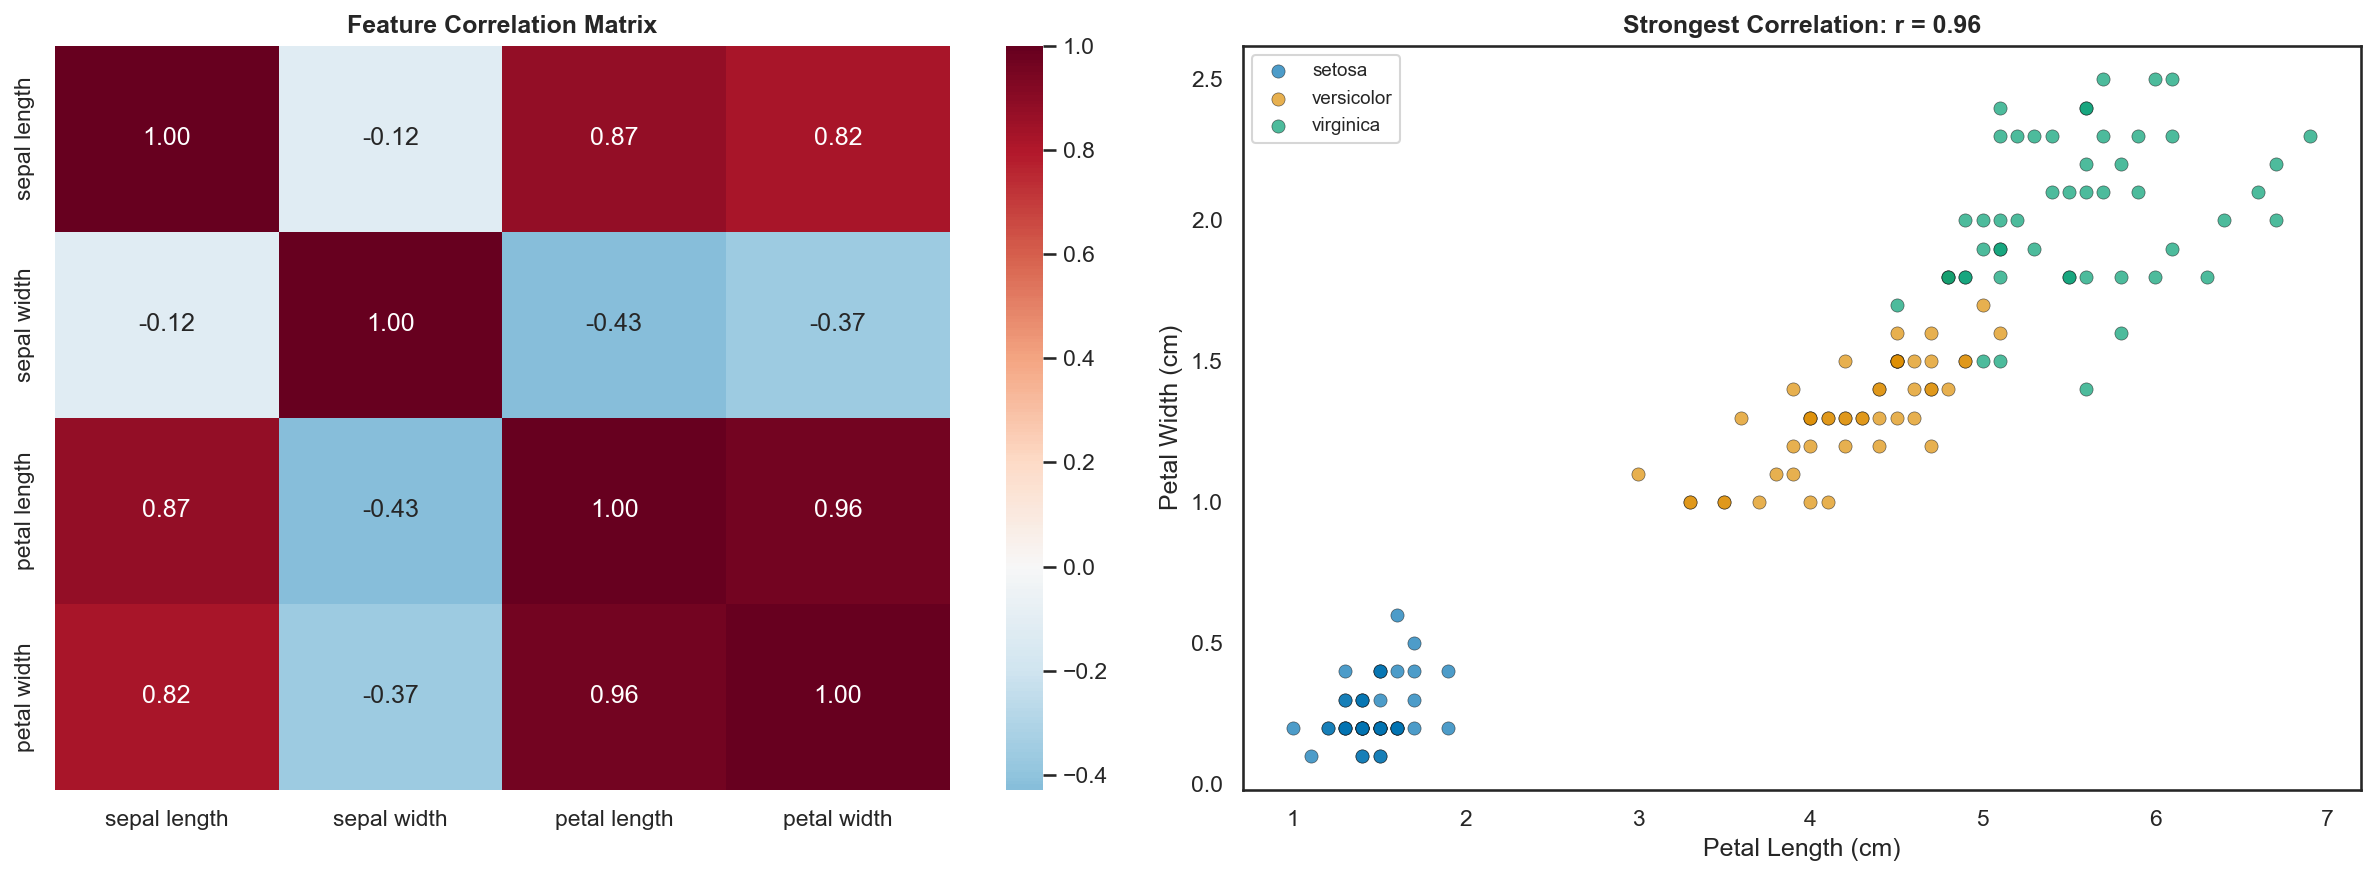

📌 Petal length and petal width are r = 0.96 correlated!
   This means they carry almost the same information.
   PCA will combine them into a single component that captures this shared variance.
   That's the whole idea — find directions that explain the most variance.


In [3]:
# Correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
corr = iris_df[feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=[f.replace(' (cm)', '') for f in feature_names],
            yticklabels=[f.replace(' (cm)', '') for f in feature_names],
            ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# Scatter: petal length vs petal width (strongest correlation)
for species in target_names:
    mask = iris_df['target'] == species
    axes[1].scatter(iris_df.loc[mask, 'petal length (cm)'],
                    iris_df.loc[mask, 'petal width (cm)'],
                    label=species, s=40, alpha=0.7, edgecolors='k', linewidth=0.3)

axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title(f'Strongest Correlation: r = {corr.loc["petal length (cm)", "petal width (cm)"]:.2f}',
                  fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("📌 Petal length and petal width are r = 0.96 correlated!")
print("   This means they carry almost the same information.")
print("   PCA will combine them into a single component that captures this shared variance.")
print("   That's the whole idea — find directions that explain the most variance.")

---

## 3. Why Scaling IS Required

PCA finds directions of **maximum variance**. If one feature has a much larger range than another, it will dominate the variance — not because it's more "important", but simply because its numbers are bigger.

`StandardScaler` normalizes all features to zero mean and unit variance, ensuring that PCA treats every feature equally.

Let's see the difference scaling makes:

Before scaling (raw feature ranges):
  sepal length (cm): mean=5.84, std=0.83, range=[4.3, 7.9]
  sepal width (cm): mean=3.06, std=0.43, range=[2.0, 4.4]
  petal length (cm): mean=3.76, std=1.76, range=[1.0, 6.9]
  petal width (cm): mean=1.20, std=0.76, range=[0.1, 2.5]

After scaling:
  sepal length (cm): mean=-0.0000, std=1.0000
  sepal width (cm): mean=-0.0000, std=1.0000
  petal length (cm): mean=-0.0000, std=1.0000
  petal width (cm): mean=-0.0000, std=1.0000


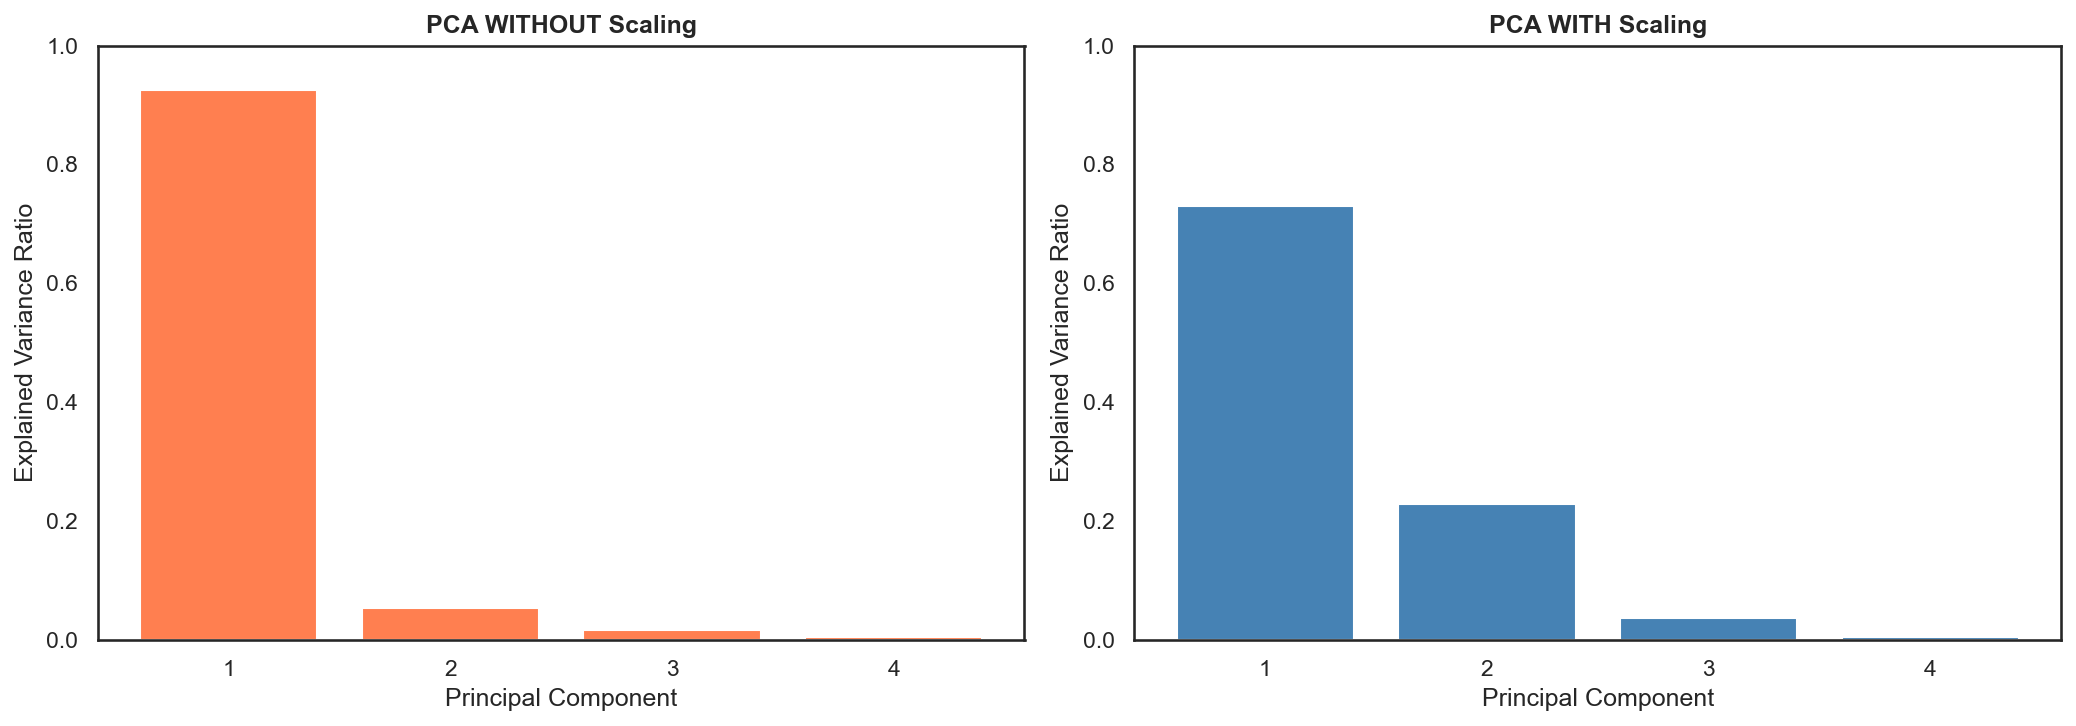

📌 Without scaling: PC1 captures 92% of variance — but that's misleading!
   It's just picking up the feature with the biggest numbers (sepal length).
   With scaling: PC1 captures ~73% — a more honest picture of the data's structure.
   Always scale before PCA unless you have a specific reason not to.


In [4]:
X = iris_df[feature_names].values
y = iris_df['target'].values

# Show raw feature ranges
print("Before scaling (raw feature ranges):")
for i, name in enumerate(feature_names):
    col = X[:, i]
    print(f"  {name}: mean={col.mean():.2f}, std={col.std():.2f}, range=[{col.min():.1f}, {col.max():.1f}]")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nAfter scaling:")
for i, name in enumerate(feature_names):
    col = X_scaled[:, i]
    print(f"  {name}: mean={col.mean():.4f}, std={col.std():.4f}")

# Compare PCA with and without scaling
pca_unscaled = PCA().fit(X)
pca_scaled = PCA().fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 5), pca_unscaled.explained_variance_ratio_, color='coral')
axes[0].set_title('PCA WITHOUT Scaling', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xticks(range(1, 5))
axes[0].set_ylim(0, 1)

axes[1].bar(range(1, 5), pca_scaled.explained_variance_ratio_, color='steelblue')
axes[1].set_title('PCA WITH Scaling', fontweight='bold')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_xticks(range(1, 5))
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("📌 Without scaling: PC1 captures 92% of variance — but that's misleading!")
print("   It's just picking up the feature with the biggest numbers (sepal length).")
print("   With scaling: PC1 captures ~73% — a more honest picture of the data's structure.")
print("   Always scale before PCA unless you have a specific reason not to.")

---

## 4. Fitting PCA: The Full Decomposition

From the theory:
> *"PCA works by identifying the principal components — new axes that maximize the variance in the data. These components are orthogonal (uncorrelated) to each other."*

From the implementation:
> We computed the covariance matrix, extracted eigenvalues/eigenvectors, sorted them by eigenvalue (largest first), and kept the top `n_components`.

scikit-learn's `PCA` does all of this with `.fit()` and `.transform()`. Let's first fit with **all 4 components** to understand the full decomposition:

In [5]:
# Fit PCA with all components
pca = PCA()  # No n_components → keeps all 4
X_pca = pca.fit_transform(X_scaled)

print("PCA fitted! Here's what scikit-learn gives us:\n")

print(f"1. .components_ (shape: {pca.components_.shape})")
print(f"   → The principal component directions (eigenvectors)")
print(f"   → Each row is one component; each column is one original feature\n")

print(f"2. .explained_variance_ (shape: {pca.explained_variance_.shape})")
print(f"   → The eigenvalues — how much variance each component captures\n")

print(f"3. .explained_variance_ratio_ (shape: {pca.explained_variance_ratio_.shape})")
print(f"   → Same as above, but as a fraction of total variance\n")

print(f"4. Transformed data (shape: {X_pca.shape})")
print(f"   → The original 150×4 data, projected onto the 4 principal components")

# Print the explained variance table
print(f"\n{'Component':<12} {'Variance':<12} {'% of Total':<12} {'Cumulative %':<12}")
print("-" * 48)
cum = 0
for i, (var, ratio) in enumerate(zip(pca.explained_variance_, pca.explained_variance_ratio_)):
    cum += ratio
    print(f"PC{i+1:<10} {var:<12.4f} {ratio*100:<12.1f} {cum*100:<12.1f}")

PCA fitted! Here's what scikit-learn gives us:

1. .components_ (shape: (4, 4))
   → The principal component directions (eigenvectors)
   → Each row is one component; each column is one original feature

2. .explained_variance_ (shape: (4,))
   → The eigenvalues — how much variance each component captures

3. .explained_variance_ratio_ (shape: (4,))
   → Same as above, but as a fraction of total variance

4. Transformed data (shape: (150, 4))
   → The original 150×4 data, projected onto the 4 principal components

Component    Variance     % of Total   Cumulative %
------------------------------------------------
PC1          2.9381       73.0         73.0        
PC2          0.9202       22.9         95.8        
PC3          0.1477       3.7          99.5        
PC4          0.0209       0.5          100.0       


---

## 5. Choosing the Number of Components

The key question in PCA: **how many components should we keep?**

The standard approach is to look at the **cumulative explained variance** and pick the number of components that captures "enough" information. Common thresholds are 90% or 95%.

Let's visualize both the per-component and cumulative explained variance:

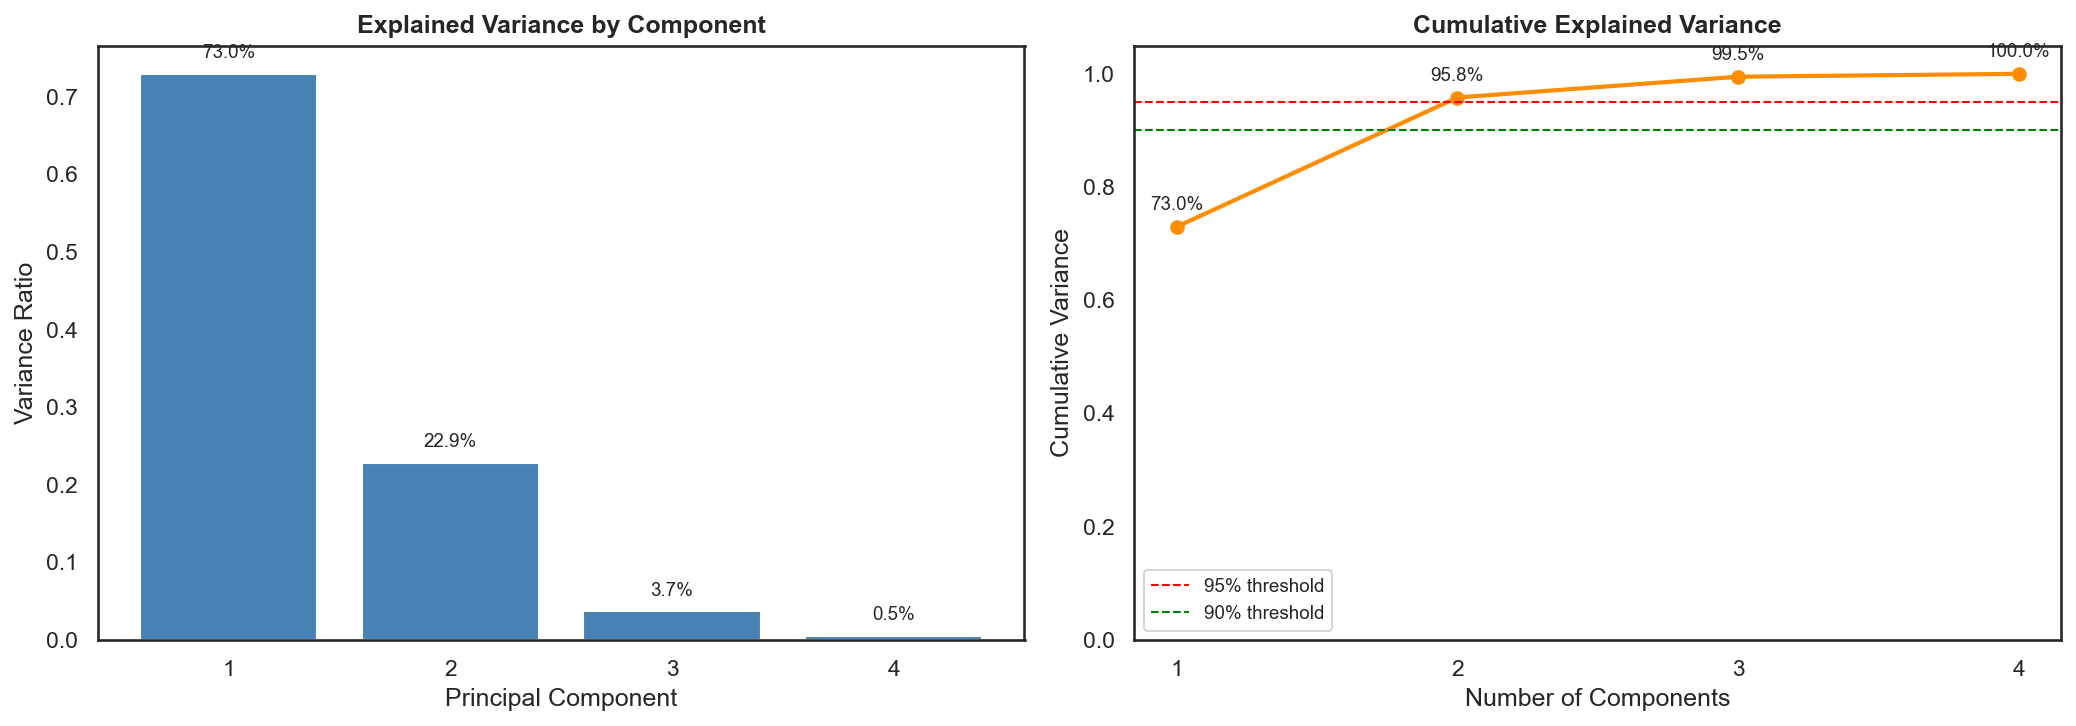

📌 PC1 alone captures ~72.8% of the variance.
   PC1 + PC2 capture ~95.8% — crossing the 95% threshold!
   This means we can reduce from 4 features to 2 and keep almost all the information.
   The 'elbow' is clearly at 2 components.


In [6]:
explained_var = pca.explained_variance_ratio_
cum_explained = explained_var.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-component
axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue')
axes[0].set_title('Explained Variance by Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_xticks(range(1, len(explained_var)+1))

# Cumulative
axes[1].plot(range(1, len(cum_explained)+1), cum_explained, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(0.95, color='red', ls='--', lw=1, label='95% threshold')
axes[1].axhline(0.90, color='green', ls='--', lw=1, label='90% threshold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_xticks(range(1, len(cum_explained)+1))
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

# Annotate
for i, (val, cum) in enumerate(zip(explained_var, cum_explained)):
    axes[0].text(i+1, val + 0.02, f'{val:.1%}', ha='center', fontsize=9)
    axes[1].text(i+1, cum + 0.03, f'{cum:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("📌 PC1 alone captures ~72.8% of the variance.")
print("   PC1 + PC2 capture ~95.8% — crossing the 95% threshold!")
print("   This means we can reduce from 4 features to 2 and keep almost all the information.")
print("   The 'elbow' is clearly at 2 components.")

---

## 6. What Do the Components Mean? The Biplot

Each principal component is a **linear combination of the original features**. The `.components_` matrix tells us the weights (loadings). Let's visualize these as arrows on the PC1–PC2 scatter plot — this is called a **biplot**:

Principal Component Loadings (how each original feature contributes):

                PC1    PC2    PC3    PC4
sepal length  0.521  0.377  0.720 -0.261
sepal width  -0.269  0.923 -0.244  0.124
petal length  0.580  0.024 -0.142  0.801
petal width   0.565  0.067 -0.634 -0.524


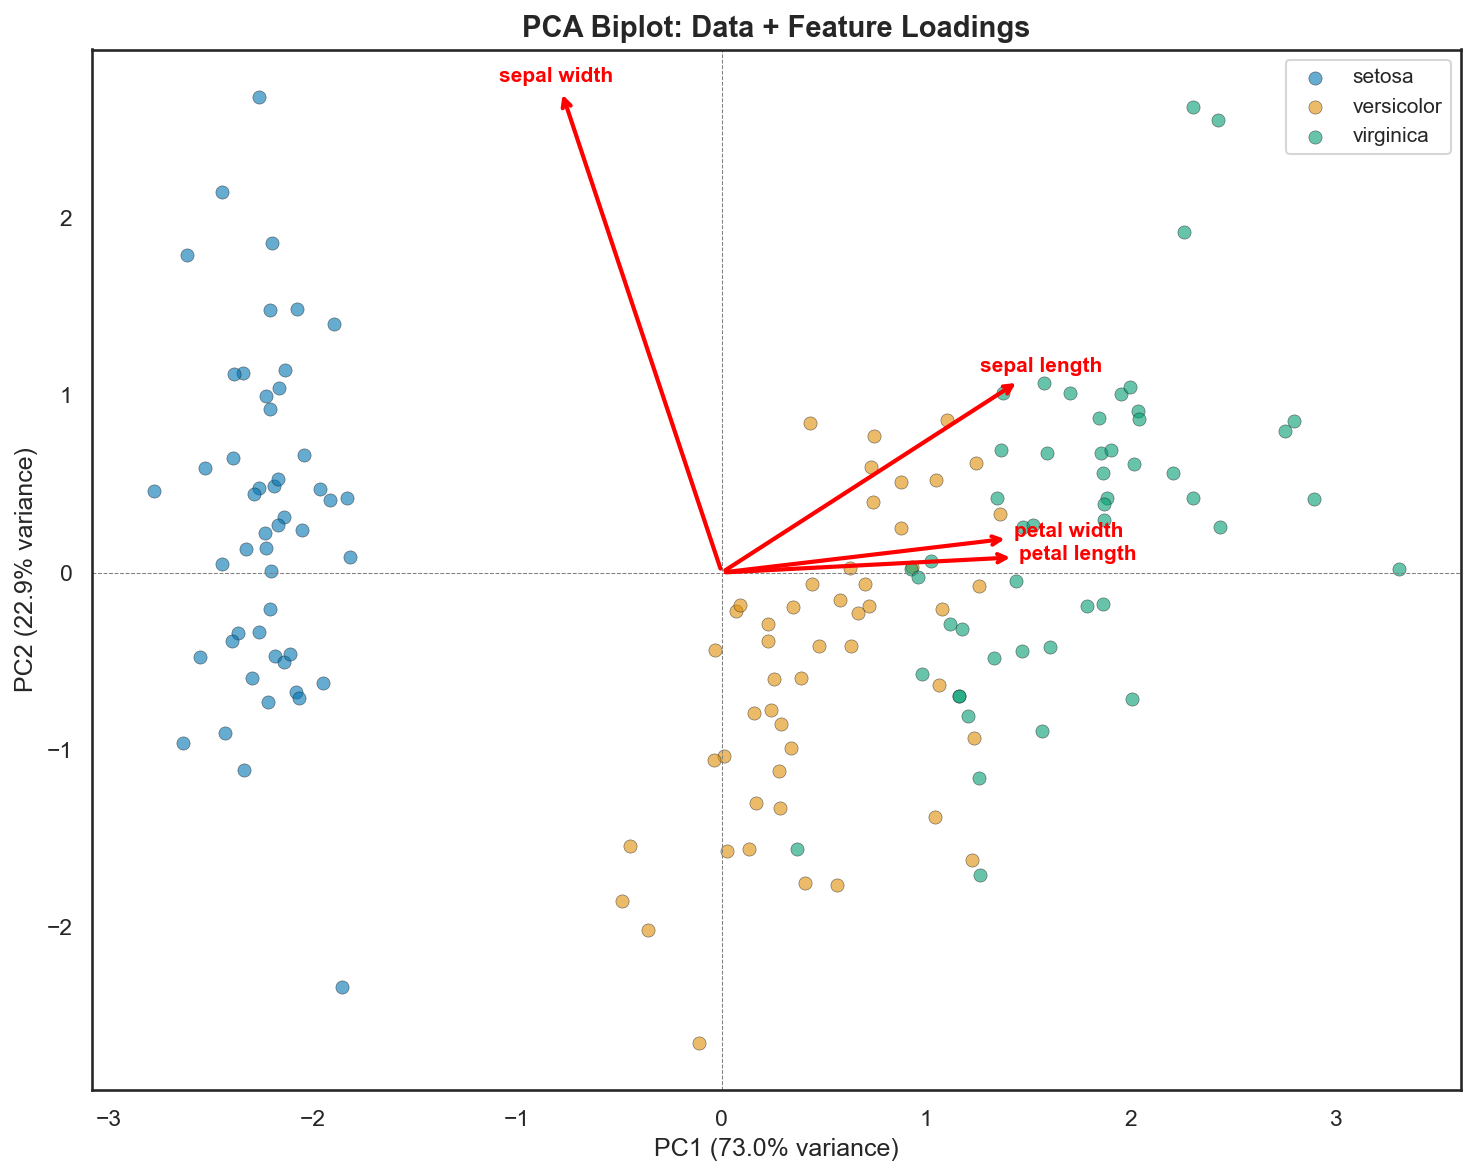

📌 Red arrows show how each original feature maps to PC1 and PC2.
   Petal length and petal width point in nearly the same direction as PC1
   → PC1 is dominated by 'petal size'.
   Sepal width points upward along PC2 → PC2 captures 'sepal width variation'.
   Arrows pointing the same way = correlated features. Arrows at 90° = uncorrelated.


In [7]:
# Print the loadings
print("Principal Component Loadings (how each original feature contributes):\n")
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(4)],
    index=[f.replace(' (cm)', '') for f in feature_names]
)
print(loadings_df.round(3).to_string())

# Biplot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter the data in PC1-PC2 space
for species in target_names:
    mask = y == species
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=species, s=40, alpha=0.6,
               edgecolors='k', linewidth=0.3)

# Draw loading arrows
arrow_scale = 3  # scale for visibility
for i, name in enumerate(feature_names):
    ax.annotate(
        name.replace(' (cm)', ''),
        xy=(0, 0),
        xytext=(pca.components_[0, i] * arrow_scale, pca.components_[1, i] * arrow_scale),
        arrowprops=dict(arrowstyle='<-', color='red', lw=2),
        fontsize=10, fontweight='bold', color='red', ha='center'
    )

ax.set_xlabel(f'PC1 ({explained_var[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained_var[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA Biplot: Data + Feature Loadings', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.axvline(0, color='gray', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

print("📌 Red arrows show how each original feature maps to PC1 and PC2.")
print("   Petal length and petal width point in nearly the same direction as PC1")
print("   → PC1 is dominated by 'petal size'.")
print("   Sepal width points upward along PC2 → PC2 captures 'sepal width variation'.")
print("   Arrows pointing the same way = correlated features. Arrows at 90° = uncorrelated.")

---

## 7. PCA for Visualization: 2D Projection

The most common use of PCA: reduce high-dimensional data to 2D for visualization. We've already seen this above, but let's make a clean version with `n_components=2`:

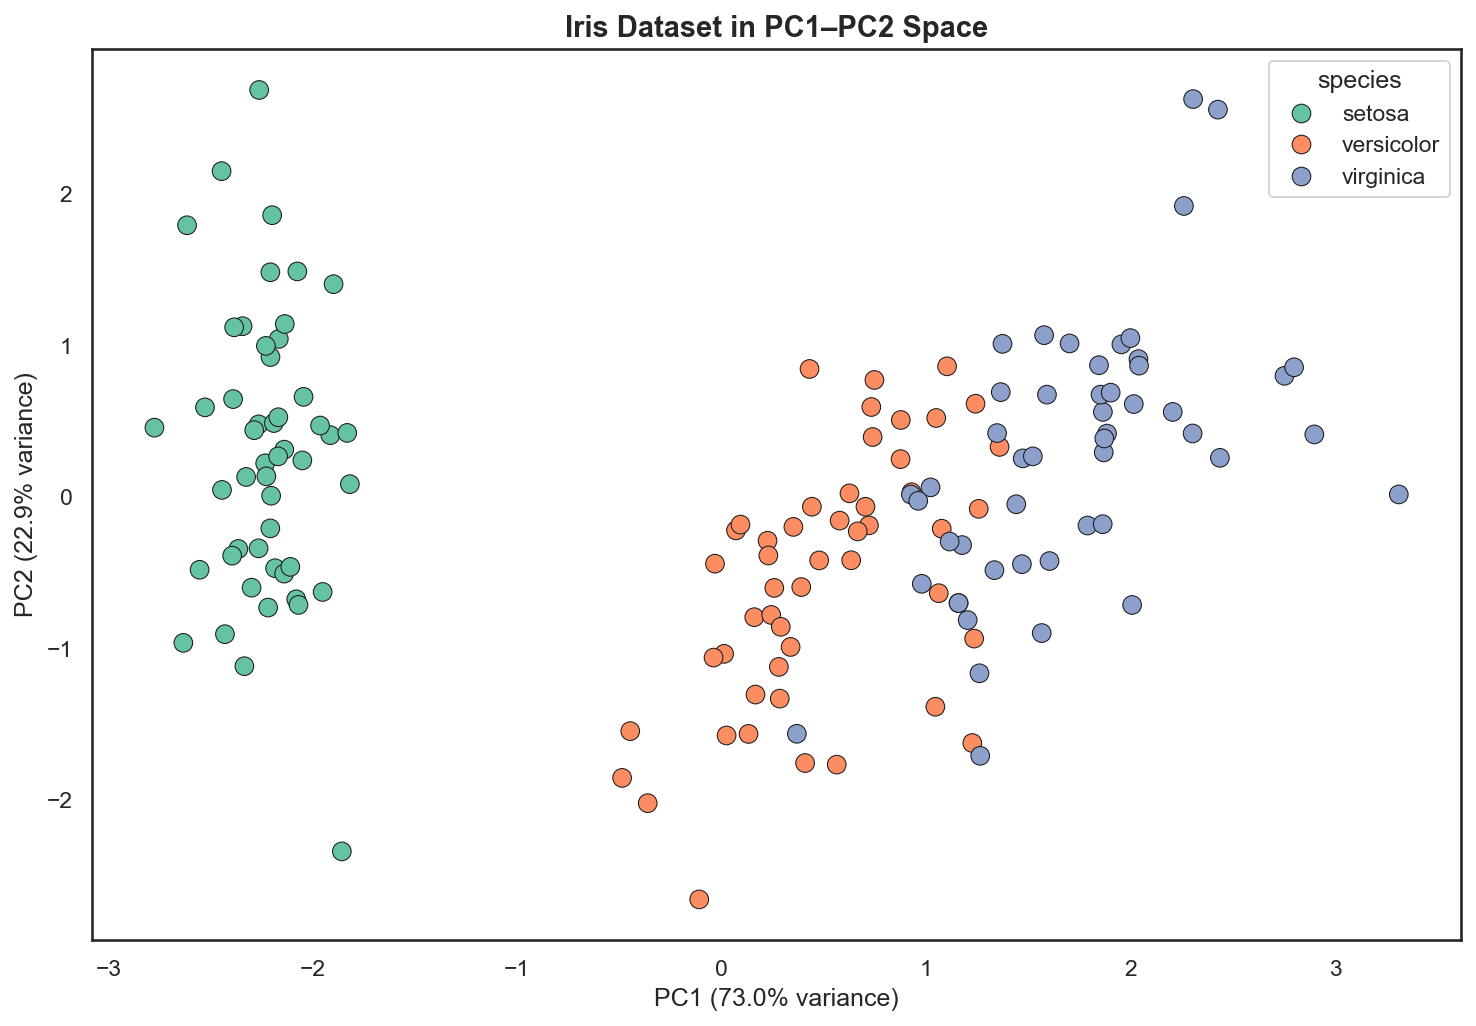

📌 Setosa (green) is cleanly separated from the other two species.
   Versicolor and virginica overlap — they're harder to distinguish.
   This 2D view captures ~95.8% of the total variance in the original 4D data!
   We went from 4 features → 2 features and lost almost no information.


In [8]:
# PCA with exactly 2 components
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# Create a DataFrame for easy plotting
pc_df = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
pc_df['species'] = y

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='species', palette='Set2',
                s=80, edgecolor='k', linewidth=0.5, ax=ax)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Iris Dataset in PC1–PC2 Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Setosa (green) is cleanly separated from the other two species.")
print("   Versicolor and virginica overlap — they're harder to distinguish.")
print("   This 2D view captures ~95.8% of the total variance in the original 4D data!")
print("   We went from 4 features → 2 features and lost almost no information.")

---

## 8. PCA for Visualization: 3D Projection

With 3 components, we can capture even more variance. Let's see the data in 3D:

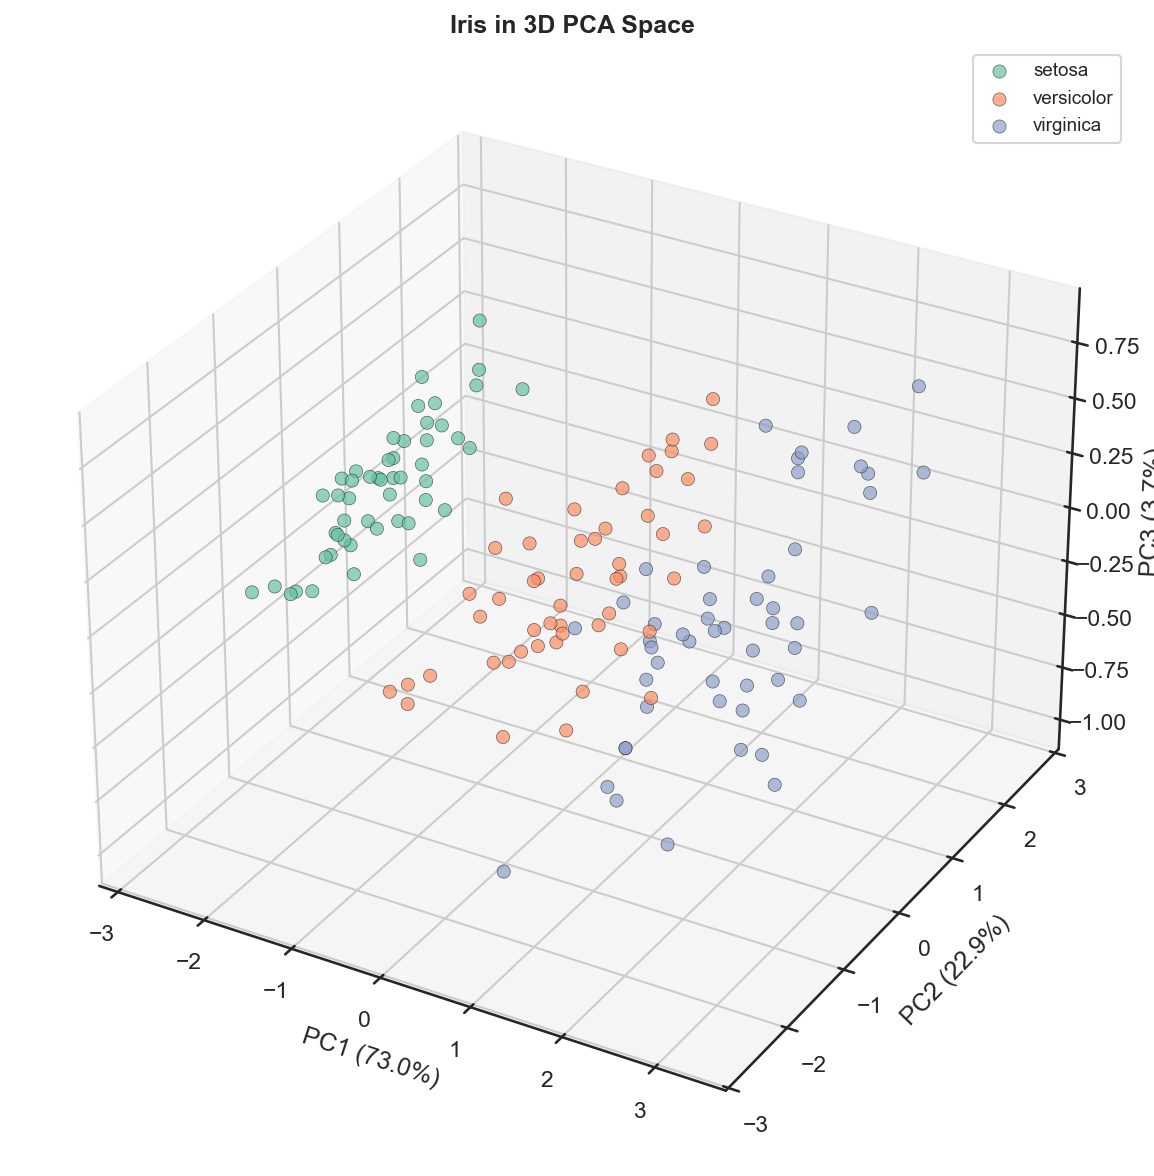

📌 3 components capture 99.5% of total variance.
   The extra PC3 adds 3.7% — a small but sometimes useful gain.
   In the 3D view, the versicolor/virginica boundary becomes slightly clearer.


In [9]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'setosa': '#66c2a5', 'versicolor': '#fc8d62', 'virginica': '#8da0cb'}
for species in target_names:
    mask = y == species
    ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
               label=species, s=40, alpha=0.7, color=colors[species], edgecolors='k', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax.set_title('Iris in 3D PCA Space', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

total_3d = pca_3d.explained_variance_ratio_.sum()
print(f"📌 3 components capture {total_3d:.1%} of total variance.")
print(f"   The extra PC3 adds {pca_3d.explained_variance_ratio_[2]:.1%} — a small but sometimes useful gain.")
print(f"   In the 3D view, the versicolor/virginica boundary becomes slightly clearer.")

---

## 9. Reconstruction: What Information Does PCA Lose?

When we reduce from 4 → 2 components, we lose some information. PCA's `inverse_transform()` lets us reconstruct the original data from the reduced representation. The difference between original and reconstructed data = **reconstruction error**.

This directly measures what the discarded components contained:

In [10]:
# Reconstruct from 2 components
X_reconstructed = pca_2d.inverse_transform(X_2d)

# Compare original vs reconstructed for a few samples
n_show = 5
print("Original (scaled) vs. Reconstructed (first 5 samples):\n")
print(f"{'Feature':<20} {'Original':<12} {'Reconstructed':<14} {'Error':<10}")
print("-" * 56)

for j in range(len(feature_names)):
    name = feature_names[j].replace(' (cm)', '')
    for i in range(n_show):
        orig = X_scaled[i, j]
        recon = X_reconstructed[i, j]
        err = abs(orig - recon)
        label = f"  [{i}] {name}" if i == 0 else f"  [{i}]"
        print(f"{label:<20} {orig:<12.4f} {recon:<14.4f} {err:<10.4f}")
    print()

# Overall reconstruction error
mse = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Mean Squared Reconstruction Error (2 components): {mse:.6f}")
print(f"\n📌 The reconstruction error is tiny — because PC1+PC2 capture ~95.8% of variance.")
print(f"   The lost information is the ~4.2% captured by PC3 and PC4.")

Original (scaled) vs. Reconstructed (first 5 samples):

Feature              Original     Reconstructed  Error     
--------------------------------------------------------
  [0] sepal length   -0.9007      -0.9989        0.0982    
  [1]                -1.1430      -1.3387        0.1957    
  [2]                -1.3854      -1.3610        0.0244    
  [3]                -1.5065      -1.4236        0.0829    
  [4]                -1.0218      -1.0011        0.0207    

  [0] sepal width    1.0190       1.0532         0.0342    
  [1]                -0.1320      -0.0619        0.0701    
  [2]                0.3284       0.3211         0.0073    
  [3]                0.0982       0.0678         0.0305    
  [4]                1.2492       1.2409         0.0083    

  [0] petal length   -1.3402      -1.3027        0.0375    
  [1]                -1.3402      -1.2243        0.1159    
  [2]                -1.3971      -1.3806        0.0165    
  [3]                -1.2834      -1.3492    

Let's visualize the reconstruction error across all components:

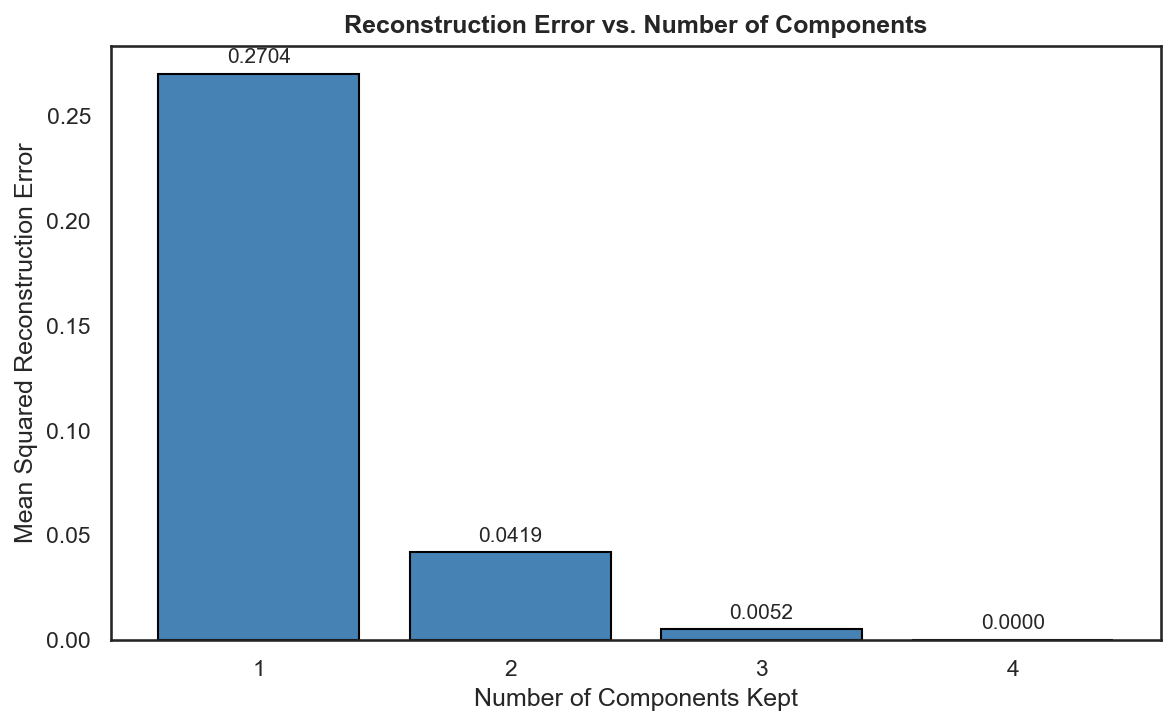

📌 With 4 components (all of them), the error is exactly 0 — no information lost.
   With 2 components, the error is very small — PCA did an excellent job compressing.
   With 1 component, the error increases significantly — too much information discarded.


In [11]:
# Reconstruction error for each number of components
n_components_list = [1, 2, 3, 4]
mse_list = []

for n in n_components_list:
    pca_n = PCA(n_components=n)
    X_n = pca_n.fit_transform(X_scaled)
    X_recon = pca_n.inverse_transform(X_n)
    mse_n = np.mean((X_scaled - X_recon) ** 2)
    mse_list.append(mse_n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([str(n) for n in n_components_list], mse_list, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Components Kept')
ax.set_ylabel('Mean Squared Reconstruction Error')
ax.set_title('Reconstruction Error vs. Number of Components', fontweight='bold')

for i, (n, mse) in enumerate(zip(n_components_list, mse_list)):
    ax.text(i, mse + 0.005, f'{mse:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("📌 With 4 components (all of them), the error is exactly 0 — no information lost.")
print("   With 2 components, the error is very small — PCA did an excellent job compressing.")
print("   With 1 component, the error increases significantly — too much information discarded.")

---

## 10. PCA's Complete API at a Glance

Let's summarize everything `sklearn.decomposition.PCA` gives us:

In [12]:
# Fit PCA with 2 components for the summary
pca_final = PCA(n_components=2)
X_final = pca_final.fit_transform(X_scaled)

print("=== PCA API Summary ===")
print()
print(f"Input:  X_scaled.shape    = {X_scaled.shape}  (samples × original features)")
print(f"Output: X_transformed.shape = {X_final.shape}  (samples × components kept)")
print()
print("Key Attributes After .fit():")
print(f"  .n_components_              = {pca_final.n_components_}")
print(f"  .components_.shape          = {pca_final.components_.shape}  (components × original features)")
print(f"  .explained_variance_        = {np.round(pca_final.explained_variance_, 4)}")
print(f"  .explained_variance_ratio_  = {np.round(pca_final.explained_variance_ratio_, 4)}")
print(f"  .mean_                      = {np.round(pca_final.mean_, 4)}  (per-feature mean used for centering)")
print(f"  .noise_variance_            = {pca_final.noise_variance_:.6f}")
print()
print("Key Methods:")
print(f"  .fit(X)             → Learn the components from X")
print(f"  .transform(X)       → Project X onto the learned components")
print(f"  .fit_transform(X)   → Fit + transform in one step")
print(f"  .inverse_transform(X_pca) → Reconstruct X from the reduced representation")

=== PCA API Summary ===

Input:  X_scaled.shape    = (150, 4)  (samples × original features)
Output: X_transformed.shape = (150, 2)  (samples × components kept)

Key Attributes After .fit():
  .n_components_              = 2
  .components_.shape          = (2, 4)  (components × original features)
  .explained_variance_        = [2.9381 0.9202]
  .explained_variance_ratio_  = [0.7296 0.2285]
  .mean_                      = [-0. -0. -0. -0.]  (per-feature mean used for centering)
  .noise_variance_            = 0.084298

Key Methods:
  .fit(X)             → Learn the components from X
  .transform(X)       → Project X onto the learned components
  .fit_transform(X)   → Fit + transform in one step
  .inverse_transform(X_pca) → Reconstruct X from the reduced representation


---

## Summary

In this lab, we learned how to use scikit-learn's `PCA` for dimensionality reduction. Here's what we covered:

| Step | What We Did | Key API |
|------|-------------|--------|
| Load data | Iris dataset (150 samples, 4 features) | `load_iris()` |
| Feature correlations | Checked that features are correlated (PCA's prerequisite) | `.corr()`, heatmap |
| Scaling required | PCA maximizes variance — unscaled features with bigger ranges dominate | `StandardScaler()` |
| Fit PCA | Full decomposition: eigenvectors + eigenvalues | `PCA().fit_transform(X)` |
| Explained variance | Per-component and cumulative variance ratios | `.explained_variance_ratio_` |
| Choose n_components | Elbow/threshold method: 2 components ≈ 95.8% variance | Cumulative variance plot |
| Biplot (loadings) | Arrows showing which features drive each component | `.components_` |
| 2D visualization | Project 4D data into 2D for visual inspection | `PCA(n_components=2)` |
| 3D visualization | Extra dimension for finer structure | `PCA(n_components=3)` |
| Reconstruction | Invert PCA to measure information loss | `.inverse_transform()` |
| API summary | All key attributes and methods in one place | Reference table |

The key takeaways:

1. **PCA finds directions of maximum variance** — the principal components are new orthogonal axes that capture the most information.
2. **Scaling is critical** — without it, features with larger ranges dominate, giving misleading results.
3. **The explained variance ratio** tells you how much information each component captures.
4. **The cumulative variance curve** (with a 90–95% threshold) guides how many components to keep.
5. **The biplot** (loading arrows) reveals what each component means in terms of the original features.
6. **`inverse_transform()`** lets you reconstruct data and quantify information loss.
7. **PCA is linear** — it only captures linear relationships. For non-linear structure, we'll need t-SNE and UMAP.

---

**Next:** [t-SNE and UMAP Lab](./12_t-sne_and_umap_lab.ipynb)